# Gauss-lengedre cuadrature

In [24]:
#quiero ver la version de qiskit
!pip show qiskit

Name: qiskit
Version: 2.5.0
Summary: An open-source SDK for working with quantum computers at the level of extended quantum circuits, operators, and primitives.
Home-page: https://www.ibm.com/quantum/qiskit
Author: 
Author-email: Qiskit Development Team <qiskit@us.ibm.com>
License-Expression: Apache-2.0
Location: /home/troncos1/Documentos/códigos/.venv/lib/python3.13/site-packages
Requires: dill, numpy, rustworkx, scipy, stevedore, typing-extensions
Required-by: ECC2025, ibm-quantum-schemas, qiskit-aer, qiskit-algorithms, qiskit-finance, qiskit-ibm-runtime, qiskit-machine-learning, qiskit-nature, qiskit-optimization, qiskit-qasm3-import, samplomatic


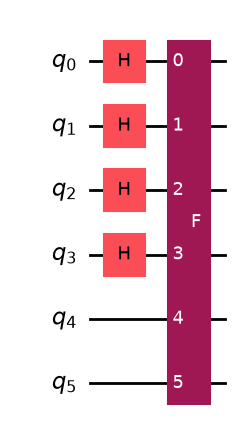

Computed (Quantum): 1.4202758446388404
Exact:              1.718281828459045


In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import LinearAmplitudeFunctionGate
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem

# FIX: Import SamplerV2 instead of the legacy V1 Sampler
from qiskit.primitives import StatevectorSampler

# 1. Configuration
num_state_qubits = 5 
total_qubits = num_state_qubits + 1 # 5 for the grid + 1 for the objective amplitude

# 2. Build the ENTIRE State Preparation Circuit
state_preparation = QuantumCircuit(total_qubits)

# Discretize the domain (Apply Hadamards to the first 3 qubits)
for i in range(0, num_state_qubits):
    state_preparation.h(i)
# state_preparation.h(range(num_state_qubits))
#display(state_preparation.draw('mpl'))

# Encode the objective function
c = (np.exp(1) - 1) / 1.0  # Slope approximation

objective_gate = LinearAmplitudeFunctionGate(
    num_state_qubits,
    slope=c,
    offset=1.0,
    domain=(0, 1),
    image=(1, np.exp(1)),
    rescaling_factor=0.2 
)
#print('objective_gate:', objective_gate)

# Append the gate to the circuit across all qubits
state_preparation.append(objective_gate, range(total_qubits))

display(state_preparation.draw('mpl'))

# 3. Define the Estimation Problem
problem = EstimationProblem(
    state_preparation=state_preparation,
    objective_qubits=[num_state_qubits], 
    post_processing=objective_gate.post_processing
)
#print('problem')

# 4. Execute Iterative Quantum Amplitude Estimation (IQAE)
sampler = Sampler()
#print('sampler:', sampler)

# 1. Elimina cualquier importación anterior del Sampler y usa esta:

# 2. Reemplaza tu bloque problemático con esto:
sampler = StatevectorSampler()

iqae = IterativeAmplitudeEstimation(
    epsilon_target=0.001, 
    alpha=0.05,          
    sampler=sampler
)

result = iqae.estimate(problem)

print(f"Computed (Quantum): {result.estimation_processed}")
print(f"Exact:              {np.exp(1) - 1}")